## NETFLIX CLEANING


In [2]:
# importing library for data handling
import pandas as pd
import numpy as np
print("done")

done


In [3]:
# loading csv file
raw="netflix.csv"
cleaned="netflix_cleaned.csv"
n=pd.read_csv(raw)


In [4]:
n

,show_id,title,type,country,release_year,rating,duration,date_added,genre
0,s053065,Stranger Things,Movie,United Kingdom,2025,NR,163,06-08-2025,NaN
1,s087994,Red Notice,Movie,France,2008,PG-13,148,31-05-2023,Adventure
2,s058832,The Office,Movie,Australia,2010,TV-PG,143,26-05-2023,Horror
3,s009282,The Good Place,Movie,United States,1992,R,99,08-07-2024,Sci-Fi
4,s083938,Bridgerton,Movie,France,1993,R,161,28-12-2020,Adventure
...,...,...,...,...,...,...,...,...,...
89995,s065954,Manifest,Movie,Japan,1992,NR,160,23-05-2023,Romance
89996,s076798,Narcos,Movie,Spain,2015,TV-MA,87,01-10-2024,Animation
89997,s075354,Ozark,TV Show,Japan,2008,TV-PG,8,01-08-2021,Thriller
89998,s015306,Elite,Movie,Australia,2001,NaN,150,08-01-2026,Action


#### DATASET INFO

In [5]:

n.shape

(90000, 9)

In [6]:
n.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       90000 non-null  object
 1   title         90000 non-null  object
 2   type          85500 non-null  object
 3   country       88203 non-null  object
 4   release_year  90000 non-null  int64 
 5   rating        78157 non-null  object
 6   duration      88501 non-null  object
 7   date_added    90000 non-null  object
 8   genre         85500 non-null  object
dtypes: int64(1), object(8)
memory usage: 6.2+ MB


In [7]:
n.isnull().sum()

show_id             0
title               0
type             4500
country          1797
release_year        0
rating          11843
duration         1499
date_added          0
genre            4500
dtype: int64

In [8]:
#Check Duplicate Rows
n.duplicated().sum()

np.int64(14)

In [9]:
#Remove Duplicate Rows
n.drop_duplicates(inplace=True)

In [10]:
#Verify Duplicate Rows After Removal
n.duplicated().sum()

np.int64(0)

In [11]:
#Identify Duplicate Show IDs
duplicates = n[n['show_id'].duplicated(keep=False)]
print(duplicates.to_string())

       show_id                 title     type           country  release_year rating duration  date_added        genre
6      s001967             Wednesday    Movie         Australia          2022  TV-14       64  31-03-2025      Romance
145    s000981              Bird Box    Movie             Spain          2007      R       69  05-03-2021      Fantasy
266    s009121             Wednesday    Movie            France          2022  TV-14       99  02-10-2019    Adventure
318    s066257                 Elite    Movie         Australia          2006  TV-MA      157  12-07-2021          NaN
340    s004646       Stranger Things    Movie         Australia          2009  TV-14      152  29-07-2021    Animation
350    s003804          Black Mirror  TV Show       South Korea          2000  TV-MA        4  04-08-2026      Romance
357    s003234                 Ozark  TV Show    United Kingdom          1996  PG-13        9  22-05-2024       Horror
380    s078192       Stranger Things  TV Show   

In [12]:
#Check Dataset Shape
n.shape

(89986, 9)

In [13]:
#Count Duplicate Show IDs
print(n['show_id'].duplicated().sum())

485


In [14]:
#Display Duplicate Show ID Records
n[n['show_id'].duplicated(keep=False)]

,show_id,title,type,country,release_year,rating,duration,date_added,genre
6,s001967,Wednesday,Movie,Australia,2022,TV-14,64,31-03-2025,Romance
145,s000981,Bird Box,Movie,Spain,2007,R,69,05-03-2021,Fantasy
266,s009121,Wednesday,Movie,France,2022,TV-14,99,02-10-2019,Adventure
318,s066257,Elite,Movie,Australia,2006,TV-MA,157,12-07-2021,NaN
340,s004646,Stranger Things,Movie,Australia,2009,TV-14,152,29-07-2021,Animation
...,...,...,...,...,...,...,...,...,...
89018,s037588,Elite,NaN,France,2023,R,47,03-08-2019,Animation
89051,s007653,You,Movie,Australia,2006,TV-14,78,15-07-2023,Thriller
89117,s079975,Ozark,Movie,India,1994,R,126,09-12-2024,Comedy
89748,s054365,Squid Game,Movie,Spain,1996,TV-MA,69,21-10-2019,Documentary


In [15]:
#Remove Duplicate Records Based on Show ID
n = n.drop_duplicates(subset='show_id', keep='first')
n = n.copy()

In [16]:
#Verify Duplicate Show IDs After Removal
print(n['show_id'].duplicated().sum())

0


In [17]:
#Check Final Dataset Shape
n.shape

(89501, 9)

In [18]:
#Generate Statistical Summary
n.describe()

,release_year
count,89501.000000
mean,2007.369448
std,11.266559
min,1900.000000
25%,1999.000000
50%,2008.000000
75%,2017.000000
max,2025.000000


In [19]:
#Check Data Types
n.dtypes

show_id         object
title           object
type            object
country         object
release_year     int64
rating          object
duration        object
date_added      object
genre           object
dtype: object

In [20]:
#Check Value Counts of Categorical Columns
for col in n.select_dtypes(include='object').columns:
    print(f"\n--- {col} ---")
    print(n[col].value_counts(dropna=False).head(20))


--- show_id ---
show_id
s088669    1
s053065    1
s087994    1
s058832    1
s009282    1
s083938    1
s022329    1
s001967    1
s011530    1
s057126    1
s073784    1
s024208    1
s029011    1
s060693    1
s089085    1
s044426    1
s038757    1
s018889    1
s035736    1
s047296    1
Name: count, dtype: int64

--- title ---
title
The Umbrella Academy    4484
Bridgerton              4483
Stranger Things         4482
Narcos                  4481
Ozark                   4480
Manifest                4479
Lucifer                 4477
Money Heist             4477
Wednesday               4476
Squid Game              4475
The Good Place          4475
Dark                    4474
Bird Box                4474
The Office              4473
Black Mirror            4473
Red Notice              4471
You                     4470
Elite                   4468
The Witcher             4466
The Crown               4463
Name: count, dtype: int64

--- type ---
type
Movie      61164
TV Show    23864
NaN      

In [21]:
#Check Unique Values in All Columns
for col in n.columns:
    print(f"\n{col}")
    print(n[col].unique())


show_id
['s053065' 's087994' 's058832' ... 's075354' 's015306' 's088669']

title
['Stranger Things' 'Red Notice' 'The Office' 'The Good Place' 'Bridgerton'
 'Bird Box' 'Wednesday' 'The Witcher' 'Squid Game' 'Money Heist'
 'Black Mirror' 'You' 'The Crown' 'Lucifer' 'Dark' 'Manifest' 'Narcos'
 'Ozark' 'Elite' 'The Umbrella Academy']

type
['Movie' 'TV Show' nan]

country
['United Kingdom' 'France' 'Australia' 'United States' 'Germany' nan
 'Canada' 'South Korea' 'Spain' 'Japan' ' India ' ' Canada ' 'India'
 ' United Kingdom ' ' Germany ' ' Spain ' ' France ' ' Australia '
 ' South Korea ' ' Japan ' ' United States ']

release_year
[2025 2008 2010 1992 1993 2007 2022 2020 2019 2009 2013 2000 1996 2001
 2017 1999 2002 2006 1991 1994 2015 1995 1997 2004 2011 2014 2003 2018
 2021 2023 1990 1998 2016 2005 2012 2024 1900]

rating
['NR' 'PG-13' 'TV-PG' 'R' 'TV-MA' 'TV-14' nan 'G' 'TV-G' 'PG']

duration
['163' '148' '143' '99' '161' '64' '177' '45' '126' '169' '131' '11' '95'
 '57' '2' '97' '11

In [22]:
n[n['show_id']=='s009121'] 

,show_id,title,type,country,release_year,rating,duration,date_added,genre
266,s009121,Wednesday,Movie,France,2022,TV-14,99,02-10-2019,Adventure


In [23]:
n.columns

Index(['show_id', 'title', 'type', 'country', 'release_year', 'rating',
       'duration', 'date_added', 'genre'],
      dtype='object')

### type → Handle Missing Type Values

In [24]:
#Check Type Distribution and Missing Values
n['type'].value_counts(dropna=False)

type
Movie      61164
TV Show    23864
NaN         4473
Name: count, dtype: int64

In [25]:
n[n['type'].isna()][['title', 'genre']].head(10)

,title,genre
45,Bird Box,Animation
49,Money Heist,Horror
93,Lucifer,Comedy
109,Money Heist,Action
135,Manifest,Romance
146,Wednesday,Crime
147,The Witcher,Horror
203,The Good Place,Fantasy
270,Black Mirror,Action
271,You,NaN


In [26]:
n[n['title']=='Stranger Things'][['title', 'type','country']].head(50)

,title,type,country
0,Stranger Things,Movie,United Kingdom
20,Stranger Things,Movie,Japan
40,Stranger Things,Movie,United States
60,Stranger Things,Movie,Japan
80,Stranger Things,TV Show,Canada
100,Stranger Things,Movie,India
120,Stranger Things,Movie,Japan
140,Stranger Things,Movie,Australia
160,Stranger Things,Movie,Canada
180,Stranger Things,Movie,South Korea


In [27]:
#Fill Missing Type Values with Unknown
n['type'] = n['type'].fillna('Unknown')

In [28]:
n['type'].isna().sum()

np.int64(0)

#### country → Standardize Country Names

In [29]:
#Check Country Values Before Cleaning
print('before - ',sorted(n['country'].dropna().unique()))

before -  [' Australia ', ' Canada ', ' France ', ' Germany ', ' India ', ' Japan ', ' South Korea ', ' Spain ', ' United Kingdom ', ' United States ', 'Australia', 'Canada', 'France', 'Germany', 'India', 'Japan', 'South Korea', 'Spain', 'United Kingdom', 'United States']


In [30]:
#Remove Extra Spaces from Country Values
n['country'] = n['country'].str.strip()
print('after - ',sorted(n['country'].dropna().unique()))

after -  ['Australia', 'Canada', 'France', 'Germany', 'India', 'Japan', 'South Korea', 'Spain', 'United Kingdom', 'United States']


In [31]:
n['country'].isna().sum()

np.int64(1793)

In [32]:
#Fill Missing Country Values Using Title
country_map = n.dropna(subset=['country']).drop_duplicates('title').set_index('title')['country']
n['country'] = n['country'].fillna(n['title'].map(country_map))

In [33]:
n['country'].isna().sum()

np.int64(0)

#### rating → Handle Missing Rating Values

In [34]:
#Check Rating Distribution and Missing Values
n['rating'].value_counts(dropna=False)

rating
TV-14    13314
TV-MA    13068
NaN      11772
PG-13    11499
PG        8958
TV-PG     8857
R         8835
G         6166
TV-G      4354
NR        2678
Name: count, dtype: int64

In [35]:
#Compare Rating Distribution by Type
pd.crosstab(n['type'], n['rating'], dropna=False)

rating,G,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,NaN
type,,,,,,,,,,
Movie,4162,1840,6131,7830,6026,9144,2999,8958,6021,8053
TV Show,1696,719,2361,3098,2339,3522,1161,3438,2397,3133
Unknown,308,119,466,571,470,648,194,672,439,586


In [36]:
#Create Rating Mapping Using Title and Type
rating_map = (
    n.dropna(subset=['rating'])
     .drop_duplicates(['title', 'type'])
     .set_index(['title', 'type'])['rating'])

In [37]:
#Fill Missing Rating Values Using Title and Type
n['rating'] = n.apply(lambda row: rating_map.get((row['title'], row['type']), row['rating']),axis=1)

In [38]:
n['rating'].isna().sum()

np.int64(0)

#### duration → Clean Duration Values 

In [39]:
n['duration'].value_counts(dropna=False)

duration
3          2323
10         2281
2          2268
8          2267
9          2253
           ... 
92          420
140         409
134         408
101         404
unknown     100
Name: count, Length: 149, dtype: int64

In [40]:
n['duration'].isna().sum()

np.int64(1494)

In [41]:
#Count Unknown Duration Values
n[n['duration'].astype(str).str.lower() == 'unknown'].shape[0]

100

In [42]:
n[n['duration'].astype(str).str.lower() == 'unknown'][['title','type','duration']].head(10)

,title,type,duration
21,Red Notice,Movie,unknown
157,Ozark,Movie,unknown
2939,The Umbrella Academy,Movie,unknown
4010,Black Mirror,Movie,unknown
4229,Money Heist,Movie,unknown
4599,The Umbrella Academy,Movie,unknown
5028,Squid Game,Unknown,unknown
6144,Bridgerton,Movie,unknown
6551,You,Movie,unknown
6754,Dark,Movie,unknown


In [43]:
#Display Records with Unknown Duration Values
n[n['title'].isin(
    n.loc[n['duration'].astype(str).str.lower() == 'unknown', 'title']
)][['title', 'type', 'duration']].head(30)

,title,type,duration
0,Stranger Things,Movie,163
1,Red Notice,Movie,148
2,The Office,Movie,143
3,The Good Place,Movie,99
4,Bridgerton,Movie,161
5,Bird Box,Movie,148
7,The Witcher,Movie,177
8,Squid Game,Movie,45
9,Money Heist,Movie,126
10,Black Mirror,Movie,169


In [44]:
n[n['title'] == 'Red Notice'][['title', 'type', 'duration']]

,title,type,duration
1,Red Notice,Movie,148
21,Red Notice,Movie,unknown
41,Red Notice,TV Show,11
61,Red Notice,TV Show,1
81,Red Notice,Movie,69
...,...,...,...
89901,Red Notice,Movie,62
89921,Red Notice,Movie,56
89941,Red Notice,Movie,163
89961,Red Notice,TV Show,7


In [45]:
n[(n['title'] == 'Red Notice') & (n['type'] == 'Movie')]['duration'].value_counts()

duration
66         35
178        35
65         32
173        31
176        31
           ..
63         13
165        13
79         12
134        11
unknown     3
Name: count, Length: 137, dtype: int64

In [46]:
#Identify Titles with Unknown Duration Values
n.loc[n['duration'].astype(str).str.lower() == 'unknown','title'].unique()

array(['Red Notice', 'Ozark', 'The Umbrella Academy', 'Black Mirror',
       'Money Heist', 'Squid Game', 'Bridgerton', 'You', 'Dark',
       'The Witcher', 'The Office', 'Bird Box', 'Narcos', 'Elite',
       'The Good Place', 'Manifest', 'Stranger Things', 'The Crown',
       'Lucifer'], dtype=object)

In [47]:
#Count Unknown Duration Values by Title
n.loc[n['duration'].astype(str).str.lower() == 'unknown','title'].value_counts()

title
You                     10
Bird Box                 9
Elite                    8
Squid Game               8
Narcos                   7
Black Mirror             6
The Office               6
Money Heist              5
The Umbrella Academy     5
Red Notice               5
Dark                     5
Manifest                 5
The Good Place           4
The Witcher              4
Bridgerton               4
Stranger Things          4
Ozark                    3
The Crown                1
Lucifer                  1
Name: count, dtype: int64

In [48]:
#Replace Unknown Duration and Fill Missing Values Using Title and Type
n.loc[
    n['duration'].astype(str).str.strip().str.lower() == 'unknown',
    'duration'
] = pd.NA

# Same title + same type-la irukkura most common duration use pannum
duration_map = n.dropna(subset=['duration']).drop_duplicates(
    ['title', 'type']
).set_index(['title', 'type'])['duration']

n['duration'] = n.apply(
    lambda row: duration_map.get((row['title'], row['type']), row['duration']),
    axis=1
)


In [49]:
n['duration'].isna().sum()

np.int64(0)

In [50]:
n.isnull().sum()

show_id            0
title              0
type               0
country            0
release_year       0
rating             0
duration           0
date_added         0
genre           4477
dtype: int64

In [57]:
n[n['duration'] == 'unknown']

,show_id,title,type,country,release_year,rating,duration,date_added,genre


#### genre → Standardize Genre Names

In [56]:
#Check Genre Distribution and Missing Values
n['genre'].value_counts(dropna=False)

genre
Animation      7000
Documentary    6997
Sci-Fi         6996
Thriller       6996
Adventure      6989
Horror         6984
Drama          6963
Romance        6960
Crime          6931
Action         6869
Fantasy        6816
Comedy         6813
NaN            4477
documentary     161
romance         153
crime           152
fantasy         151
comedy          147
drama           141
horror          141
adventure       139
animation       135
action          133
sci-fi          132
thriller        125
Name: count, dtype: int64

In [57]:
n['genre'].isna().sum()

np.int64(4477)

In [58]:
#Standardize Genre Values by Removing Spaces and Formatting Text
n['genre'] = n['genre'].str.strip().str.title()

In [59]:
#Verify Genre Values After Standardization
n['genre'].value_counts(dropna=False)

genre
Documentary    7158
Animation      7135
Adventure      7128
Sci-Fi         7128
Horror         7125
Thriller       7121
Romance        7113
Drama          7104
Crime          7083
Action         7002
Fantasy        6967
Comedy         6960
NaN            4477
Name: count, dtype: int64

In [60]:
n[n['genre'].isna()][['title', 'type', 'genre']].head(20)

,title,type,genre
0,Stranger Things,Movie,NaN
35,Manifest,Movie,NaN
56,Narcos,Movie,NaN
72,The Crown,Movie,NaN
86,Wednesday,Movie,NaN
87,The Witcher,Movie,NaN
117,Ozark,Movie,NaN
138,Elite,Movie,NaN
167,The Witcher,Movie,NaN
191,You,Movie,NaN


In [61]:
#Fill Missing Genre Values Using Title
genre_map = (
    n.dropna(subset=['genre'])
     .drop_duplicates('title')
     .set_index('title')['genre']
)

n['genre'] = n['genre'].fillna(n['title'].map(genre_map))

In [62]:
n['genre'].isna().sum()

np.int64(0)

In [63]:
n.isnull().sum()

show_id         0
title           0
type            0
country         0
release_year    0
rating          0
duration        0
date_added      0
genre           0
dtype: int64

In [64]:
#Save the Cleaned Dataset as a CSV File
n.to_csv(cleaned)

In [76]:
import matplotlib.pyplot as plt

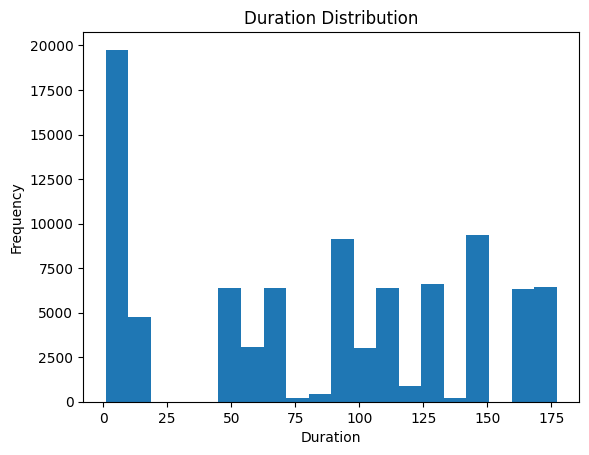

In [77]:
#Plot Duration Distribution Using Histogram
plt.hist(duration_num.dropna(), bins=20)
plt.title('Duration Distribution')
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.show()

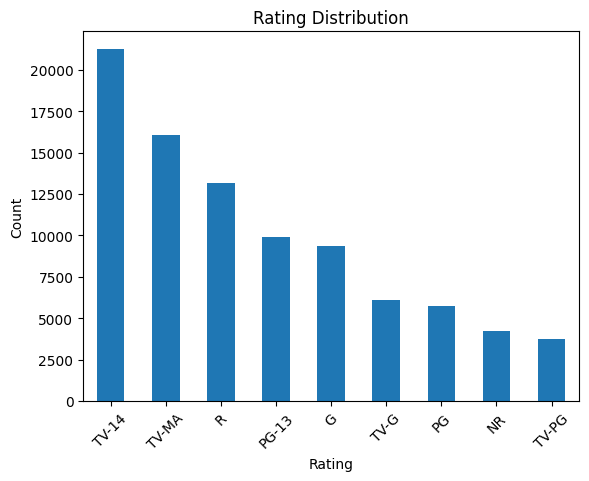

In [78]:
#Plot Rating Distribution Using Bar Chart
n['rating'].value_counts().plot(kind='bar')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [79]:
n.dtypes

show_id                 object
title                   object
type                    object
country                 object
release_year             int64
rating                  object
duration                object
date_added      datetime64[ns]
genre                   object
dtype: object

In [80]:
# Convert date_added column to datetime format
# Convert date_added from DD-MM-YYYY format to datetime
n['date_added'] = pd.to_datetime(n['date_added'], format='%d-%m-%Y')

In [81]:
# Display some date values from date_added
n['date_added'].head(20)

0    2025-08-06
1    2023-05-31
2    2023-05-26
3    2024-07-08
4    2020-12-28
5    2024-04-22
6    2025-03-31
7    2024-03-22
8    2023-05-18
9    2019-05-19
10   2022-05-30
11   2024-08-08
12   2020-08-11
13   2022-05-15
14   2022-09-12
15   2022-05-05
16   2026-02-24
17   2025-03-07
18   2026-04-22
19   2020-08-19
Name: date_added, dtype: datetime64[ns]

In [82]:
n.dtypes


show_id                 object
title                   object
type                    object
country                 object
release_year             int64
rating                  object
duration                object
date_added      datetime64[ns]
genre                   object
dtype: object

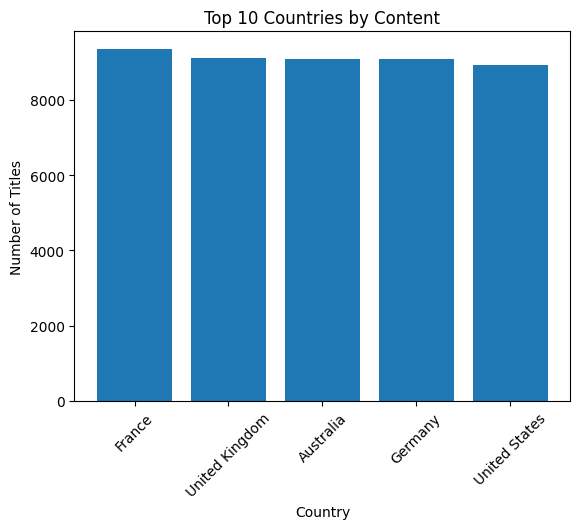

In [83]:
# Find the top 10 countries by content count
country_count = n['country'].value_counts().head(5)

# Plot top 10 countries
plt.bar(country_count.index, country_count.values)

plt.title('Top 10 Countries by Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

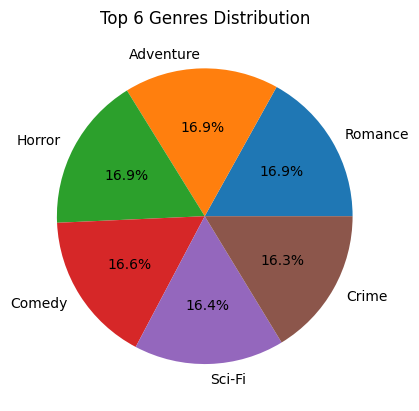

In [84]:
# Count the top 6 genres
genre_count = n['genre'].value_counts().head(6)

# Create a pie chart
plt.pie(
    genre_count.values,
    labels=genre_count.index,
    autopct='%1.1f%%'
)

plt.title('Top 6 Genres Distribution')
plt.show()